# 🏠 House Price Prediction — End-to-End Data Science Project
**Author:** Puskar Ghosal  
**Dataset:** Housing.csv (545 rows × 13 columns)  
**Goal:** Predict house prices using EDA, feature engineering, and ML models

---

## 📋 Table of Contents
1. [Setup & Imports](#1-setup)
2. [Data Loading & Exploration](#2-data-loading)
3. [Data Cleaning & Feature Engineering](#3-cleaning)
4. [Exploratory Data Analysis](#4-eda)
5. [Visualizations](#5-visualizations)
6. [Feature Selection](#6-feature-selection)
7. [Model Building](#7-model-building)
8. [Model Diagnostics](#8-diagnostics)
9. [Business Insights](#9-insights)
10. [Executive Summary](#10-summary)


## 1. Setup & Imports <a id='1-setup'></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')



os.makedirs('charts', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("✅ All imports successful")


✅ All imports successful


## 2. Data Loading & Exploration <a id='2-data-loading'></a>

We start by loading the dataset and performing a thorough initial inspection.  
Understanding the data structure before any analysis is a fundamental best practice.


In [2]:
df = pd.read_csv('Housing.csv')
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [3]:
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Dataset shape: 545 rows × 13 columns


In [4]:
# Datatypes and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
# Separate target variable
target = df['price']

num_cols = df.drop('price', axis=1)\
             .select_dtypes(
                 include=['int64', 'float64']
             ).columns.tolist()

cat_cols = df.drop('price', axis=1)\
             .select_dtypes(
                 include=['object']
             ).columns.tolist()
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)


Numerical columns: ['area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Categorical columns: ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']


In [6]:
# Statistical summary of numerical features
df[num_cols].describe().round(2)


,area,bedrooms,bathrooms,stories,parking
count,545.00,545.00,545.00,545.00,545.00
mean,5150.54,2.97,1.29,1.81,0.69
std,2170.14,0.74,0.50,0.87,0.86
min,1650.00,1.00,1.00,1.00,0.00
25%,3600.00,2.00,1.00,1.00,0.00
50%,4600.00,3.00,1.00,2.00,0.00
75%,6360.00,3.00,2.00,2.00,1.00
max,16200.00,6.00,4.00,4.00,3.00


In [7]:
# Missing value analysis
# since there is no missing value we'll not impute missing values . 
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [8]:
# Duplicate analysis
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")


Duplicate rows: 0


In [9]:
# Unique Categorical Values
for col in cat_cols :
    print(f'{col} --> {df[col].unique()} --> {len(df[col].unique())} categgories')

mainroad --> ['yes' 'no'] --> 2 categgories
guestroom --> ['no' 'yes'] --> 2 categgories
basement --> ['no' 'yes'] --> 2 categgories
hotwaterheating --> ['no' 'yes'] --> 2 categgories
airconditioning --> ['yes' 'no'] --> 2 categgories
prefarea --> ['yes' 'no'] --> 2 categgories
furnishingstatus --> ['furnished' 'semi-furnished' 'unfurnished'] --> 3 categgories


In [10]:
# Memory usage
mem = df.memory_usage(deep=True).sum() / 1024
print(f"Memory usage: {mem:.2f} KB")


Memory usage: 221.92 KB


## 3. Data Cleaning & Feature Engineering <a id='3-cleaning'></a>

### What we do here
- Handle outliers using the IQR method
- Encode categorical variables (binary → 0/1, nominal → one-hot)
- Create new derived features that add predictive power

### Why
Clean data improves model accuracy and prevents garbage-in-garbage-out issues.


In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Features and target
X = df.drop('price', axis=1)
y = df['price']

# Categorical columns
binary_cols = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

# Preprocessor definition only
preprocessor = ColumnTransformer(
    transformers=[
        (
            'binary',
            OneHotEncoder(
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
            ),
            binary_cols
        ),
        (
            'furnishing',
            OneHotEncoder(
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
            ),
            ['furnishingstatus']
        )
    ],
    remainder='passthrough'
)

In [12]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [13]:
# Outlier detection using IQR
def detect_outliers_iqr(series, col_name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = series[(series < lower) | (series > upper)]

    print(
        f"{col_name}: Q1={Q1:.0f}, Q3={Q3:.0f}, "
        f"IQR={IQR:.0f}, Lower={lower:.0f}, "
        f"Upper={upper:.0f}, Outliers={len(outliers)}"
    )

    return lower, upper


price_lo, price_hi = detect_outliers_iqr(df['price'], 'price')
area_lo, area_hi = detect_outliers_iqr(df['area'], 'area')

price: Q1=3430000, Q3=5740000, IQR=2310000, Lower=-35000, Upper=9205000, Outliers=15
area: Q1=3600, Q3=6360, IQR=2760, Lower=-540, Upper=10500, Outliers=12


In [14]:
# Outlier Treatment

# Treat outliers using capping (winsorization)

df['price'] = df['price'].clip(price_lo, price_hi)

df['area'] = df['area'].clip(area_lo, area_hi)

In [15]:
# CHECKING OUTLIER 

price_lo_new, price_hi_new = detect_outliers_iqr(df['price'], 'price')
area_lo_new, area_hi_new = detect_outliers_iqr(df['area'], 'area')

price: Q1=3430000, Q3=5740000, IQR=2310000, Lower=-35000, Upper=9205000, Outliers=0
area: Q1=3600, Q3=6360, IQR=2760, Lower=-540, Upper=10500, Outliers=0


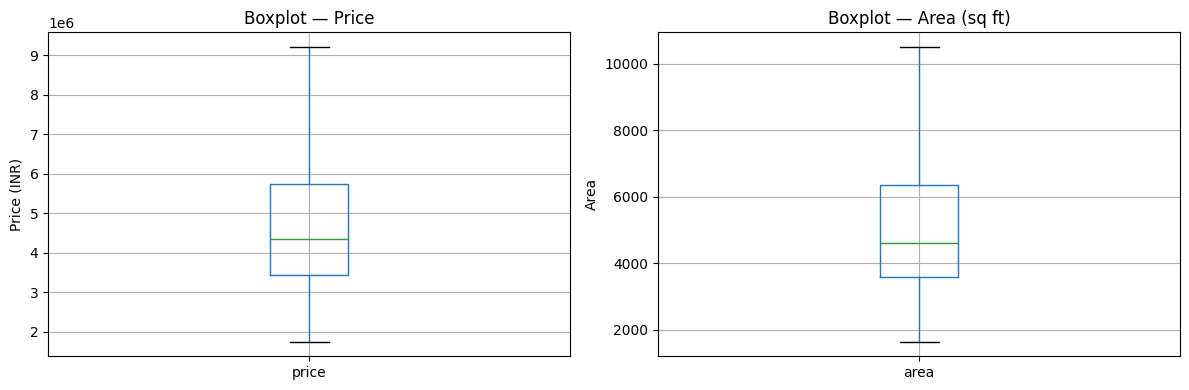

Chart saved.


In [16]:


# Visualize after treatment
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(column='price', ax=axes[0])
axes[0].set_title('Boxplot — Price')
axes[0].set_ylabel('Price (INR)')

df.boxplot(column='area', ax=axes[1])
axes[1].set_title('Boxplot — Area (sq ft)')
axes[1].set_ylabel('Area')

plt.tight_layout()
plt.savefig('charts/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved.")

In [17]:
# Outliers were capped instead of removed because they represent
# genuinely large/expensive houses and contain useful information.

print(f"Dataset shape after outlier treatment: {df.shape}")

Dataset shape after outlier treatment: (545, 13)


In [18]:
# Feature Engineering

df['area_per_bedroom'] = df['area'] / df['bedrooms']

df['bath_bed_ratio'] = df['bathrooms'] / df['bedrooms']

df['luxury_score'] = (
    (df['airconditioning'] == 'yes').astype(int)
    + (df['hotwaterheating'] == 'yes').astype(int)
    + (df['prefarea'] == 'yes').astype(int)
    + (df['guestroom'] == 'yes').astype(int)
)

print("Derived features added:")

print(
    df[
        ['area_per_bedroom',
         'bath_bed_ratio',
         'luxury_score']
    ].describe().round(2)
)

Derived features added:
       area_per_bedroom  bath_bed_ratio  luxury_score
count            545.00          545.00        545.00
mean            1804.43            0.45          0.77
std              795.12            0.16          0.83
min              381.00            0.17          0.00
25%             1237.50            0.33          0.00
50%             1666.67            0.40          1.00
75%             2180.00            0.50          1.00
max             5250.00            1.00          3.00


## 4. Exploratory Data Analysis <a id='4-eda'></a>

Deep EDA helps us understand the relationship between features and price.  
Every chart is followed by a business interpretation.


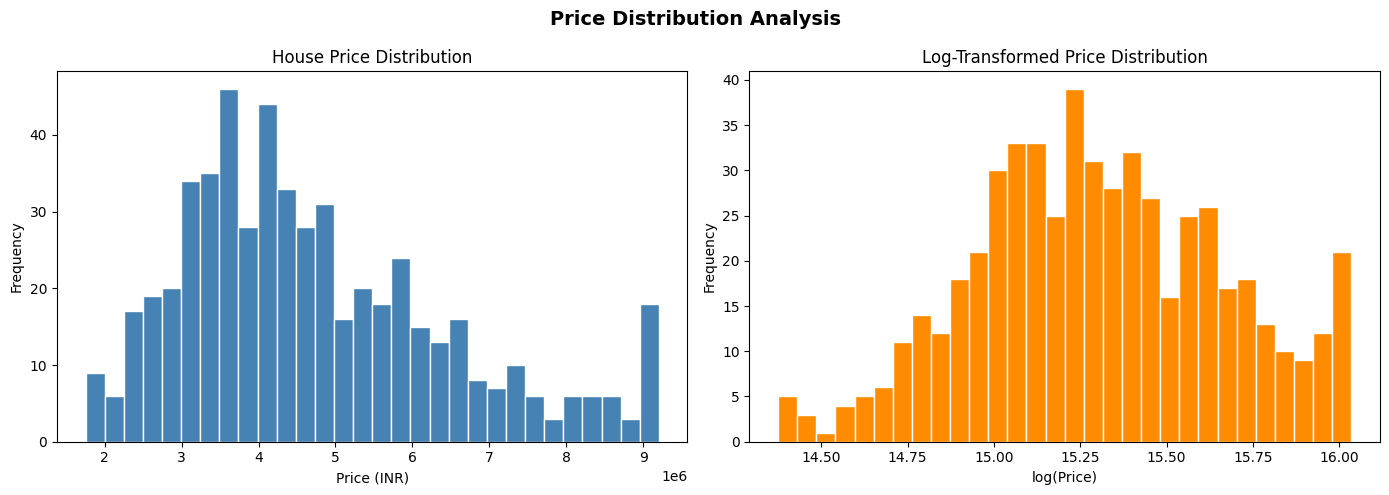

In [19]:
# Price distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df['price'],
    bins=30,
    color='steelblue',
    edgecolor='white'
)
axes[0].set_title('House Price Distribution')
axes[0].set_xlabel('Price (INR)')
axes[0].set_ylabel('Frequency')

axes[1].hist(
    np.log1p(df['price']),
    bins=30,
    color='darkorange',
    edgecolor='white'
)
axes[1].set_title('Log-Transformed Price Distribution')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle(
    'Price Distribution Analysis',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig(
    'charts/house_price_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

**📌 Insight:** Price distribution is right-skewed, meaning a small number of very expensive houses pull the mean up. Log transformation makes it approximately normal — this is important for Linear Regression.

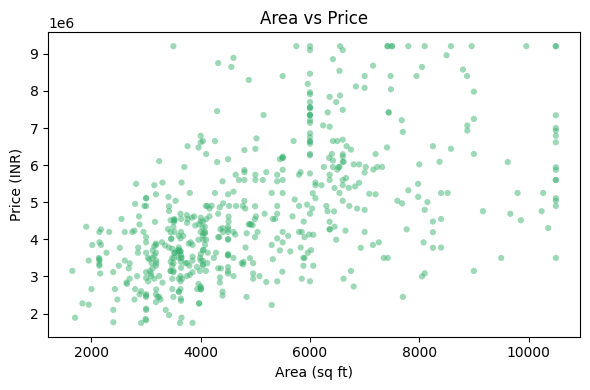

In [20]:
# Area vs Price scatter

plt.figure(figsize=(6, 4))

plt.scatter(
    df['area'],
    df['price'],
    alpha=0.5,
    color='mediumseagreen',
    edgecolors='none',
    s=20
)

plt.title('Area vs Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (INR)')

plt.tight_layout()
plt.show()

In [21]:
# Bedrooms vs Price

avg_price_bed = (
    df.groupby('bedrooms')['price']
      .mean()
      .reset_index()
)

avg_price_bed

,bedrooms,price
0,1,2.712500e+06
1,2,3.632022e+06
2,3,4.934881e+06
3,4,5.576274e+06
4,5,5.725300e+06
5,6,4.791500e+06


In [23]:
plt.figure(figsize=(6,4))
plt.bar(avg_price_bed['remainder__bedrooms'], avg_price_bed['remainder__price'], color = ['red' , 'green' ,'blue' , 'mediumseagreen' , 'yellow' 
                                                                                          , 'pink' ], edgecolor='white')
plt.title('Average Price by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Avg Price (INR)')
plt.tight_layout()
plt.show()

KeyError: 'remainder__bedrooms'

<Figure size 600x400 with 0 Axes>

In [23]:
# Bedrooms vs Price
avg_price_bath = df_transformed.groupby('remainder__bathrooms')['remainder__price'].mean().reset_index()
avg_price_bath


,remainder__bathrooms,remainder__price
0,1.0,4.206913e+06
1,2.0,6.209206e+06
2,3.0,7.282100e+06
3,4.0,1.225000e+07


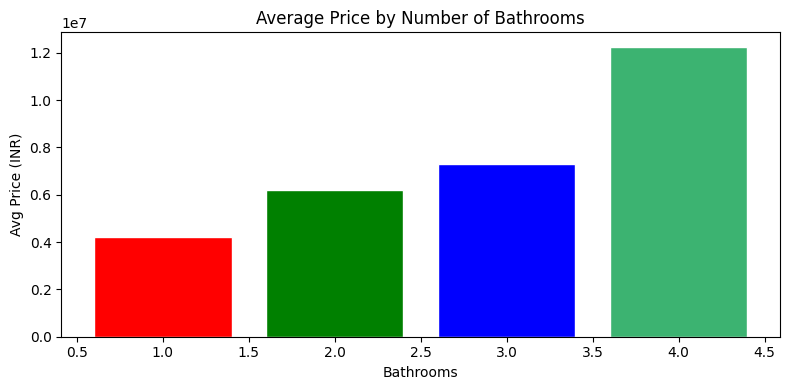

In [24]:
# Bathrooms vs Price
plt.figure(figsize=(8, 4))
plt.bar(avg_price_bath['remainder__bathrooms'], avg_price_bath['remainder__price'], color = ['red' , 'green' ,'blue' , 'mediumseagreen' , 
                                                                                             'yellow' ], edgecolor='white')
                                                                                        
plt.title('Average Price by Number of Bathrooms')
plt.xlabel('Bathrooms')
plt.ylabel('Avg Price (INR)')
plt.tight_layout()
plt.show()


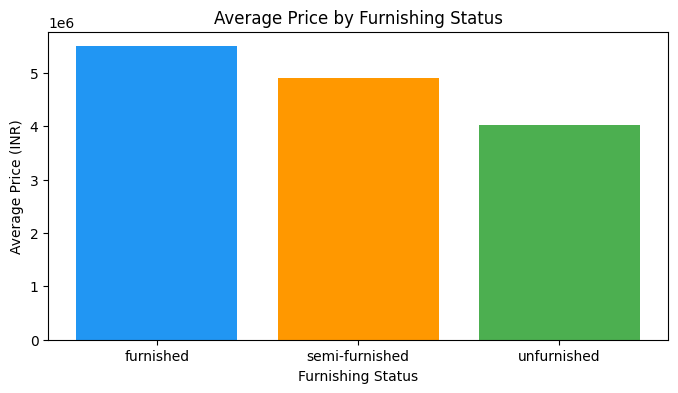

In [25]:
furnish_map = {}

# Furnished (dropped category)
furnish_map['furnished'] = df_transformed[
    (df_transformed['furnishing__furnishingstatus_semi-furnished'] == 0) &
    (df_transformed['furnishing__furnishingstatus_unfurnished'] == 0)
]['remainder__price'].mean()

# Semi-furnished
furnish_map['semi-furnished'] = df_transformed[
    df_transformed['furnishing__furnishingstatus_semi-furnished'] == 1
]['remainder__price'].mean()

# Unfurnished
furnish_map['unfurnished'] = df_transformed[
    df_transformed['furnishing__furnishingstatus_unfurnished'] == 1
]['remainder__price'].mean()

plt.figure(figsize=(8,4))
plt.bar(furnish_map.keys(), furnish_map.values() , color=['#2196F3','#FF9800','#4CAF50'])

plt.title('Average Price by Furnishing Status')
plt.xlabel('Furnishing Status')
plt.ylabel('Average Price (INR)')
plt.show()

In [26]:
# AC impact on price
ac_map = {}
ac_map['With AC'] = df_transformed[df_transformed['binary__airconditioning_yes'] == 1]['remainder__price'].mean()
ac_map['No AC'] = df_transformed[df_transformed['binary__airconditioning_yes'] == 0]['remainder__price'].mean()

ac_map


{'With AC': np.float64(6013220.5813953485),
 'No AC': np.float64(4191939.678284182)}

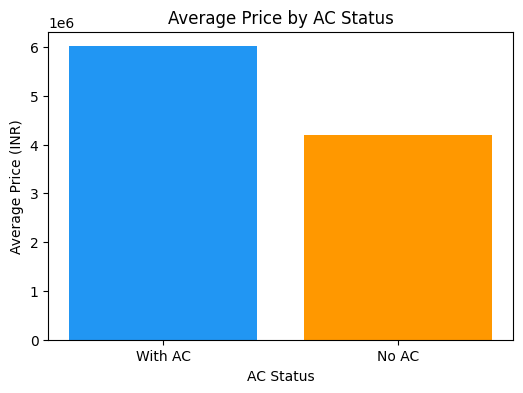

AC increases avg price by: 43.4%


In [27]:
plt.figure(figsize=(6,4))
plt.bar(ac_map.keys(), ac_map.values() , color=['#2196F3','#FF9800','#4CAF50'])

plt.title('Average Price by AC Status')
plt.xlabel('AC Status')
plt.ylabel('Average Price (INR)')
plt.show()
pct_increase = (ac_map['With AC'] - ac_map['No AC']) / ac_map['No AC'] * 100
print(f"AC increases avg price by: {pct_increase:.1f}%")

In [28]:
# Main road impact
road_map = {}
road_map['On Main Road'] = df_transformed[df_transformed['binary__mainroad_yes'] == 1]['remainder__price'].mean()
road_map['Not On Main Road'] = df_transformed[df_transformed['binary__mainroad_yes'] == 0]['remainder__price'].mean()

road_map



{'On Main Road': np.float64(4991777.329059829),
 'Not On Main Road': np.float64(3398904.5454545454)}

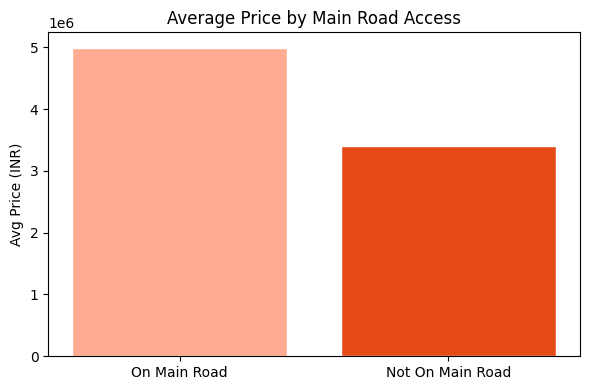

AC increases avg price by: 46.9%


In [29]:
plt.figure(figsize=(6, 4))
plt.bar(road_map.keys() , road_map.values() , color=['#FFAB91','#E64A19'], edgecolor='white')
plt.title('Average Price by Main Road Access')
plt.ylabel('Avg Price (INR)')
plt.tight_layout()
plt.show()
pct_increase = (road_map['On Main Road'] - road_map['Not On Main Road']) / road_map['Not On Main Road'] * 100
print(f"AC increases avg price by: {pct_increase:.1f}%")

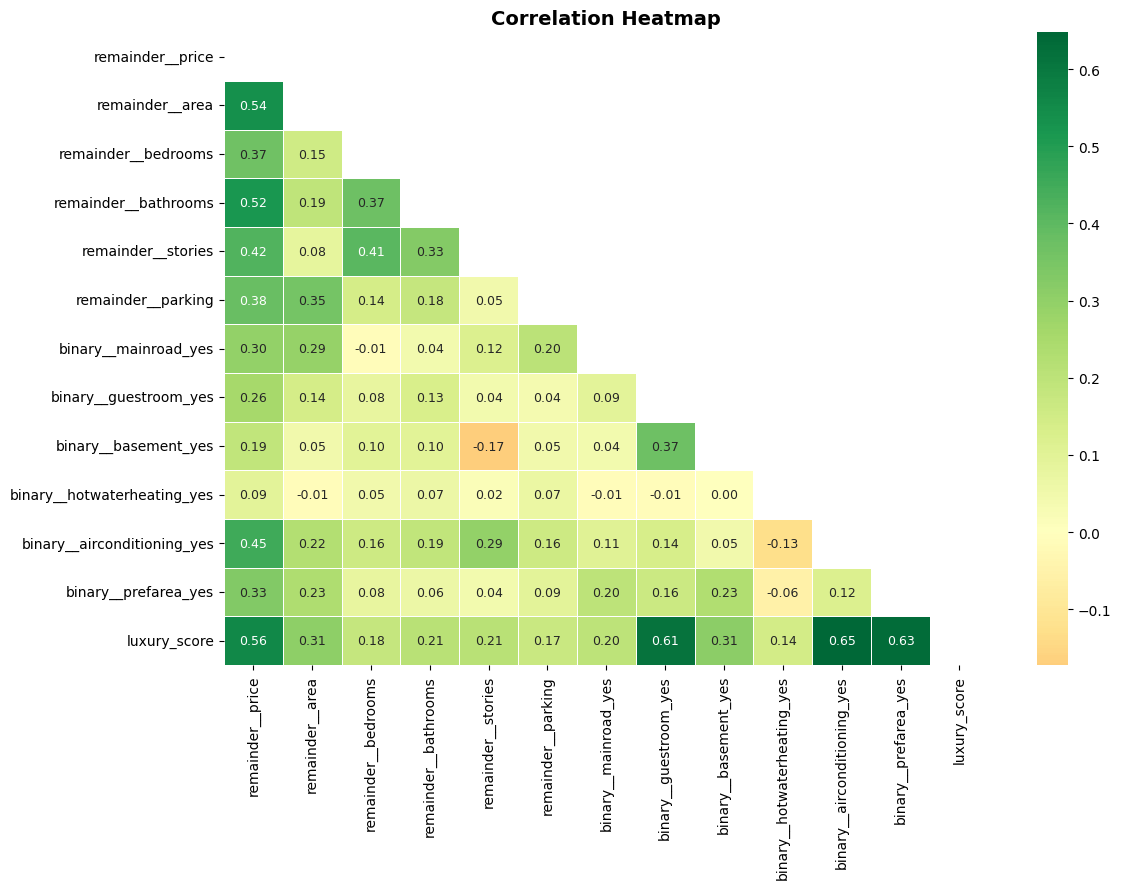

In [30]:
# Correlation matrix
corr_cols = ['remainder__price', 'remainder__area', 'remainder__bedrooms', 'remainder__bathrooms', 'remainder__stories', 'remainder__parking',
             'binary__mainroad_yes', 'binary__guestroom_yes', 'binary__basement_yes', 'binary__hotwaterheating_yes',
             'binary__airconditioning_yes', 'binary__prefarea_yes', 'luxury_score']

corr_matrix = df_transformed[corr_cols].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


In [31]:
# Top correlations with price
price_corr = corr_matrix['remainder__price'].drop('remainder__price').sort_values(ascending=False)
print("Top correlations with Price:")
print(price_corr.round(3))


Top correlations with Price:
luxury_score                   0.560
remainder__area                0.536
remainder__bathrooms           0.518
binary__airconditioning_yes    0.453
remainder__stories             0.421
remainder__parking             0.384
remainder__bedrooms            0.366
binary__prefarea_yes           0.330
binary__mainroad_yes           0.297
binary__guestroom_yes          0.256
binary__basement_yes           0.187
binary__hotwaterheating_yes    0.093
Name: remainder__price, dtype: float64


## 5. Additional Visualizations <a id='5-visualizations'></a>

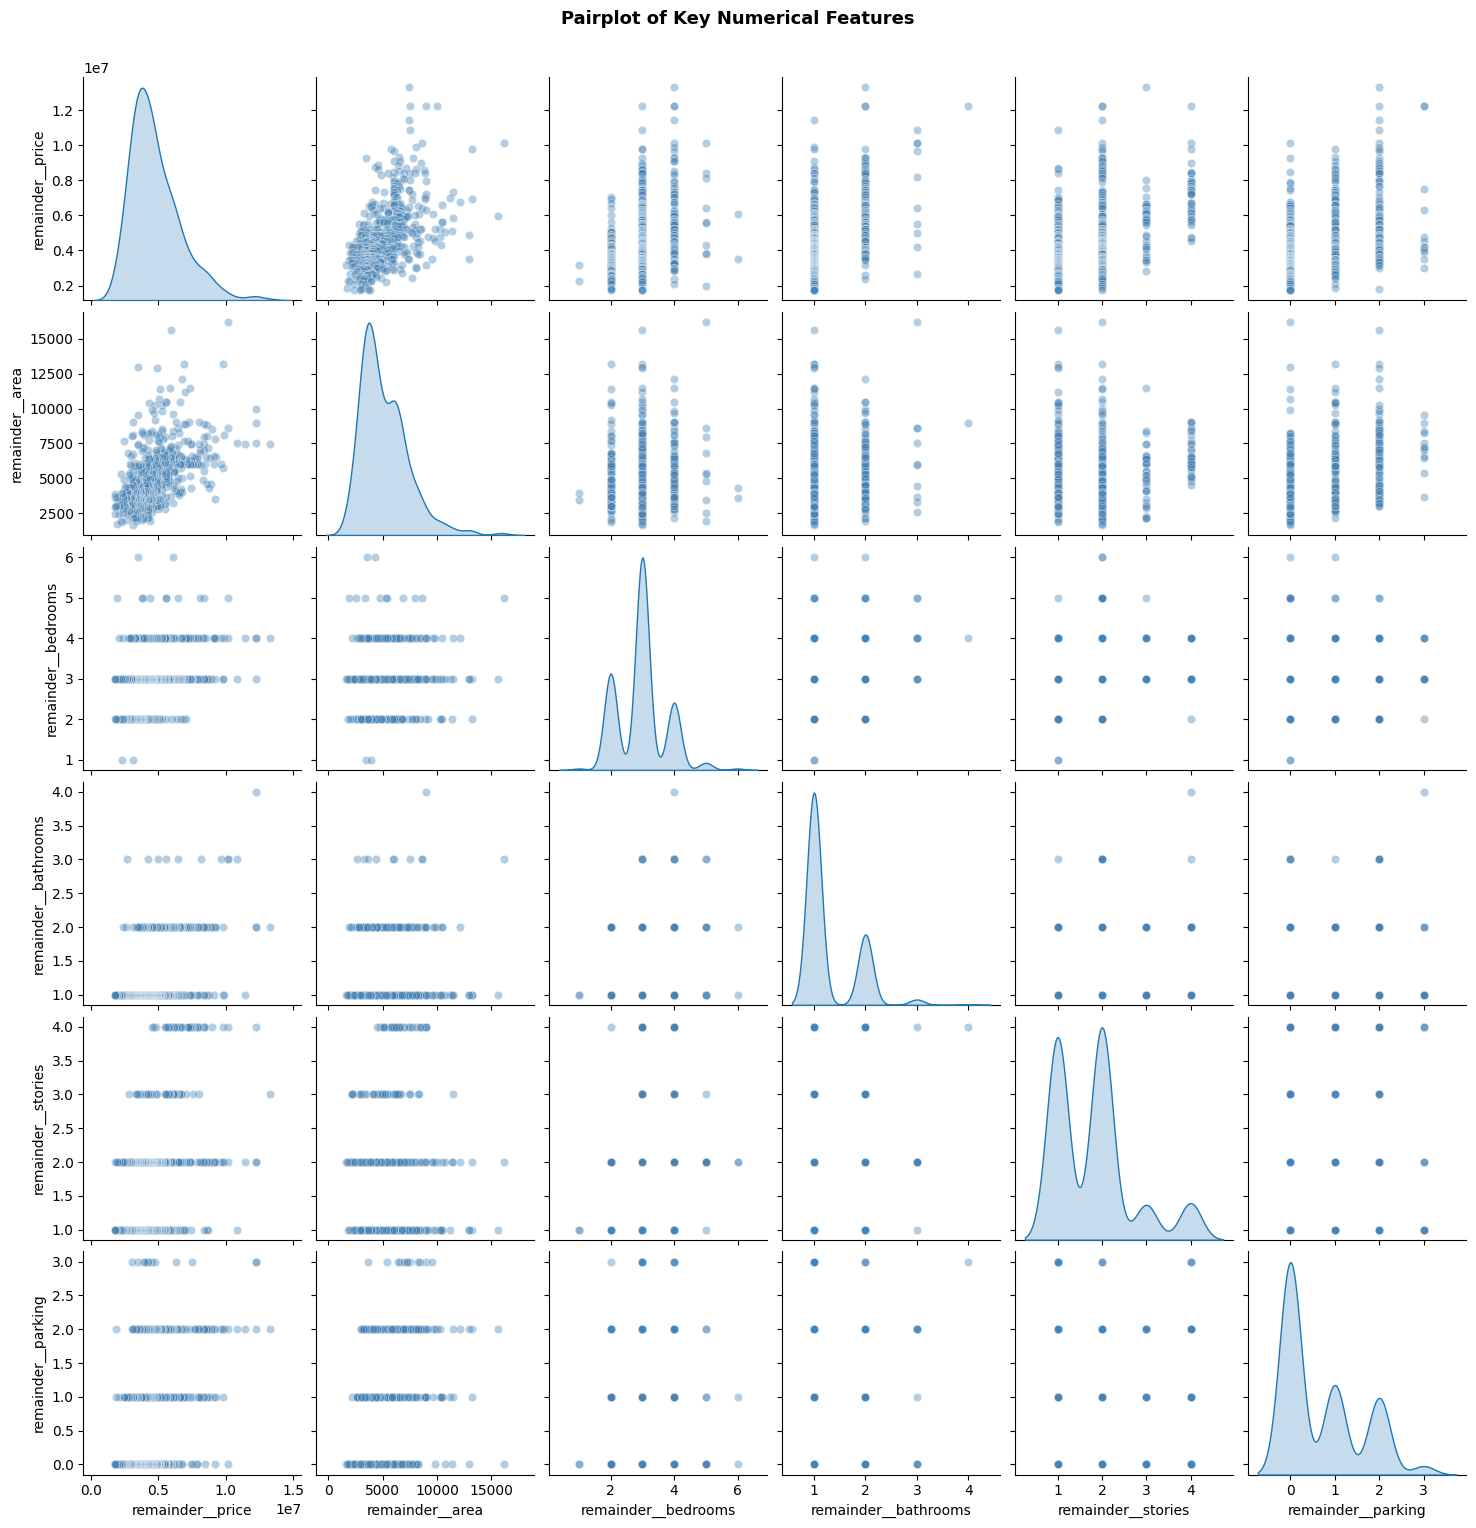

In [32]:
# Pairplot of key numerical features
key_cols = ['remainder__price', 'remainder__area', 'remainder__bedrooms', 'remainder__bathrooms', 'remainder__stories', 'remainder__parking']
pair_data = df_transformed[key_cols].copy()

fig = sns.pairplot(pair_data, diag_kind='kde', plot_kws={'alpha': 0.4, 'color': 'steelblue'})
fig.fig.suptitle('Pairplot of Key Numerical Features', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('charts/additional_visualizations.png', dpi=120, bbox_inches='tight')
plt.show()


## 6. Feature Selection <a id='6-feature-selection'></a>

We identify the most important predictors before training models.  
This reduces noise, speeds up training, and improves generalisation.


In [33]:
df_transformed.head()

,binary__mainroad_yes,binary__guestroom_yes,binary__basement_yes,binary__hotwaterheating_yes,binary__airconditioning_yes,binary__prefarea_yes,furnishing__furnishingstatus_semi-furnished,furnishing__furnishingstatus_unfurnished,remainder__price,remainder__area,remainder__bedrooms,remainder__bathrooms,remainder__stories,remainder__parking,area_per_bedroom,bath_bed_ratio,luxury_score
0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,13300000.0,7420.0,4.0,2.0,3.0,2.0,1855.0,0.500000,2.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,12250000.0,8960.0,4.0,4.0,4.0,3.0,2240.0,1.000000,1.0
2,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,12250000.0,9960.0,3.0,2.0,2.0,2.0,3320.0,0.666667,1.0
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,12215000.0,7500.0,4.0,2.0,2.0,3.0,1875.0,0.500000,2.0
4,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,11410000.0,7420.0,4.0,1.0,2.0,2.0,1855.0,0.250000,2.0


In [34]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler

# Prepare feature matrix

X = df_transformed.drop(columns='remainder__price')
y = df_transformed['remainder__price']

print(f"Feature matrix shape: {X.shape}")
print("Features:", X.columns.tolist())


Feature matrix shape: (545, 16)
Features: ['binary__mainroad_yes', 'binary__guestroom_yes', 'binary__basement_yes', 'binary__hotwaterheating_yes', 'binary__airconditioning_yes', 'binary__prefarea_yes', 'furnishing__furnishingstatus_semi-furnished', 'furnishing__furnishingstatus_unfurnished', 'remainder__area', 'remainder__bedrooms', 'remainder__bathrooms', 'remainder__stories', 'remainder__parking', 'area_per_bedroom', 'bath_bed_ratio', 'luxury_score']


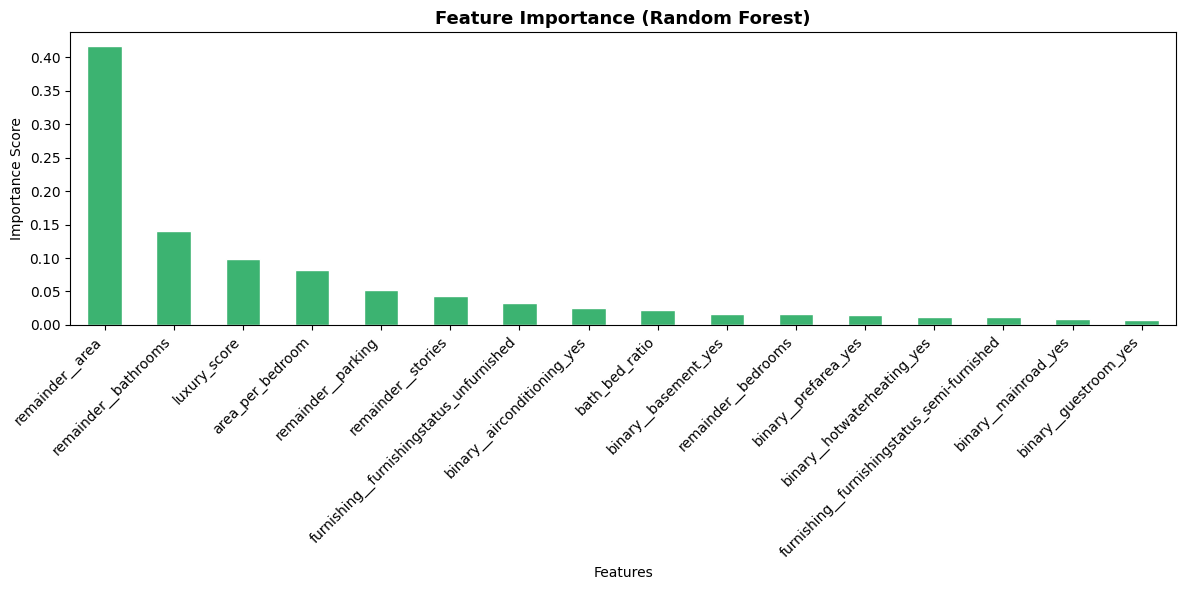


Top 5 features:
remainder__area         0.416175
remainder__bathrooms    0.140258
luxury_score            0.098479
area_per_bedroom        0.082016
remainder__parking      0.051524
dtype: float64


In [35]:
# Quick RF to get feature importances before full tuning
rf_prelim = RandomForestRegressor(n_estimators=100, random_state=42)
rf_prelim.fit(X, y)

feat_imp = pd.Series(rf_prelim.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
feat_imp.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Feature Importance (Random Forest)', fontsize=13, fontweight='bold')
plt.ylabel('Importance Score')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('charts/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features:")
print(feat_imp.head())


## 7. Model Building <a id='7-model-building'></a>

### Train / Test Split: 80% / 20%  
We train two models:
1. **Linear Regression** — baseline, interpretable
2. **Random Forest** — ensemble, handles non-linearity


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=10
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")


Train size: 436 | Test size: 109


In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train Linear Regression
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_test_scaled = scaler.transform(X_test)

y_train_log = np.log1p(y_train)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train_log)

y_pred_log = lr.predict(X_test_scaled)
y_pred_lr = np.expm1(y_pred_log)
print("Linear Regression trained ✅")


Linear Regression trained ✅


In [48]:
# Evaluate Linear Regression

def evaluate_model(y_true, y_pred, model_name, n_features):
    mae   = mean_absolute_error(y_true, y_pred)
    mse   = mean_squared_error(y_true, y_pred)
    rmse  = np.sqrt(mse)
    r2    = r2_score(y_true, y_pred)
    n     = len(y_true)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    print(f"\n{'='*40}")
    print(f"  {model_name}")
    print(f"{'='*40}")
    print(f"  MAE      : {mae:>15,.0f}")
    print(f"  MSE      : {mse:>15,.0f}")
    print(f"  RMSE     : {rmse:>15,.0f}")
    print(f"  R²       : {r2:>15.4f}")
    print(f"  Adj. R²  : {adj_r2:>15.4f}")
    return {'Model': model_name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2, 'Adj_R2': adj_r2}

results_lr = evaluate_model(y_test, y_pred_lr, "Linear Regression", X_train_scaled.shape[1])



  Linear Regression
  MAE      :         646,812
  MSE      : 655,687,782,715
  RMSE     :         809,746
  R²       :          0.7668
  Adj. R²  :          0.7262


In [51]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_cv = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(rf_cv, param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
grid_search.fit(X_train_scaled, y_train_log)

print("Best parameters:", grid_search.best_params_)
print("Best CV R²:", round(grid_search.best_score_, 4))


Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R²: 0.6102


In [52]:
# Train best RF
rf_best = grid_search.best_estimator_
y_pred_log = rf_best.predict(X_test_scaled)
y_pred_rf = np.expm1(y_pred_log)

results_rf = evaluate_model(y_test, y_pred_rf, "Random Forest (Tuned)", X_train_scaled.shape[1])



  Random Forest (Tuned)
  MAE      :         717,646
  MSE      : 1,030,703,872,967
  RMSE     :       1,015,236
  R²       :          0.6334
  Adj. R²  :          0.5697


In [53]:
# Comparison table
results_df = pd.DataFrame([results_lr, results_rf])
results_df = results_df.set_index('Model')
results_df[['MAE','RMSE','R2','Adj_R2']] = results_df[['MAE','RMSE','R2','Adj_R2']].round(4)
print("\n📊 Model Comparison Table:")
print(results_df.to_string())



📊 Model Comparison Table:
                               MAE           MSE          RMSE      R2  Adj_R2
Model                                                                         
Linear Regression      646812.2527  6.556878e+11  8.097455e+05  0.7668  0.7262
Random Forest (Tuned)  717646.0379  1.030704e+12  1.015236e+06  0.6334  0.5697


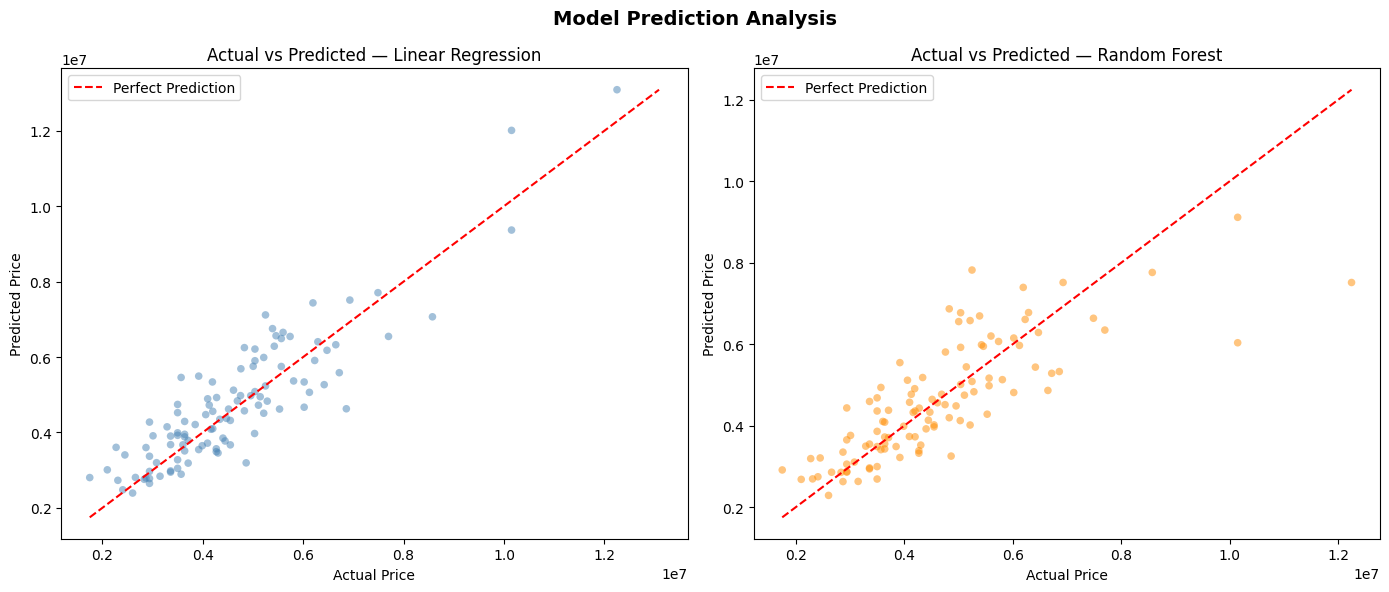

In [54]:
# Actual vs Predicted — both models side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title, color in zip(
        axes,
        [y_pred_lr, y_pred_rf],
        ['Linear Regression', 'Random Forest'],
        ['steelblue', 'darkorange']):

    ax.scatter(y_test, y_pred, alpha=0.5, color=color, edgecolors='none', s=30)
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfect Prediction')
    ax.set_title(f'Actual vs Predicted — {title}')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.legend()

plt.suptitle('Model Prediction Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/model_prediction_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Model Diagnostics <a id='8-diagnostics'></a>

Residual analysis helps detect systematic errors and confirm model assumptions.


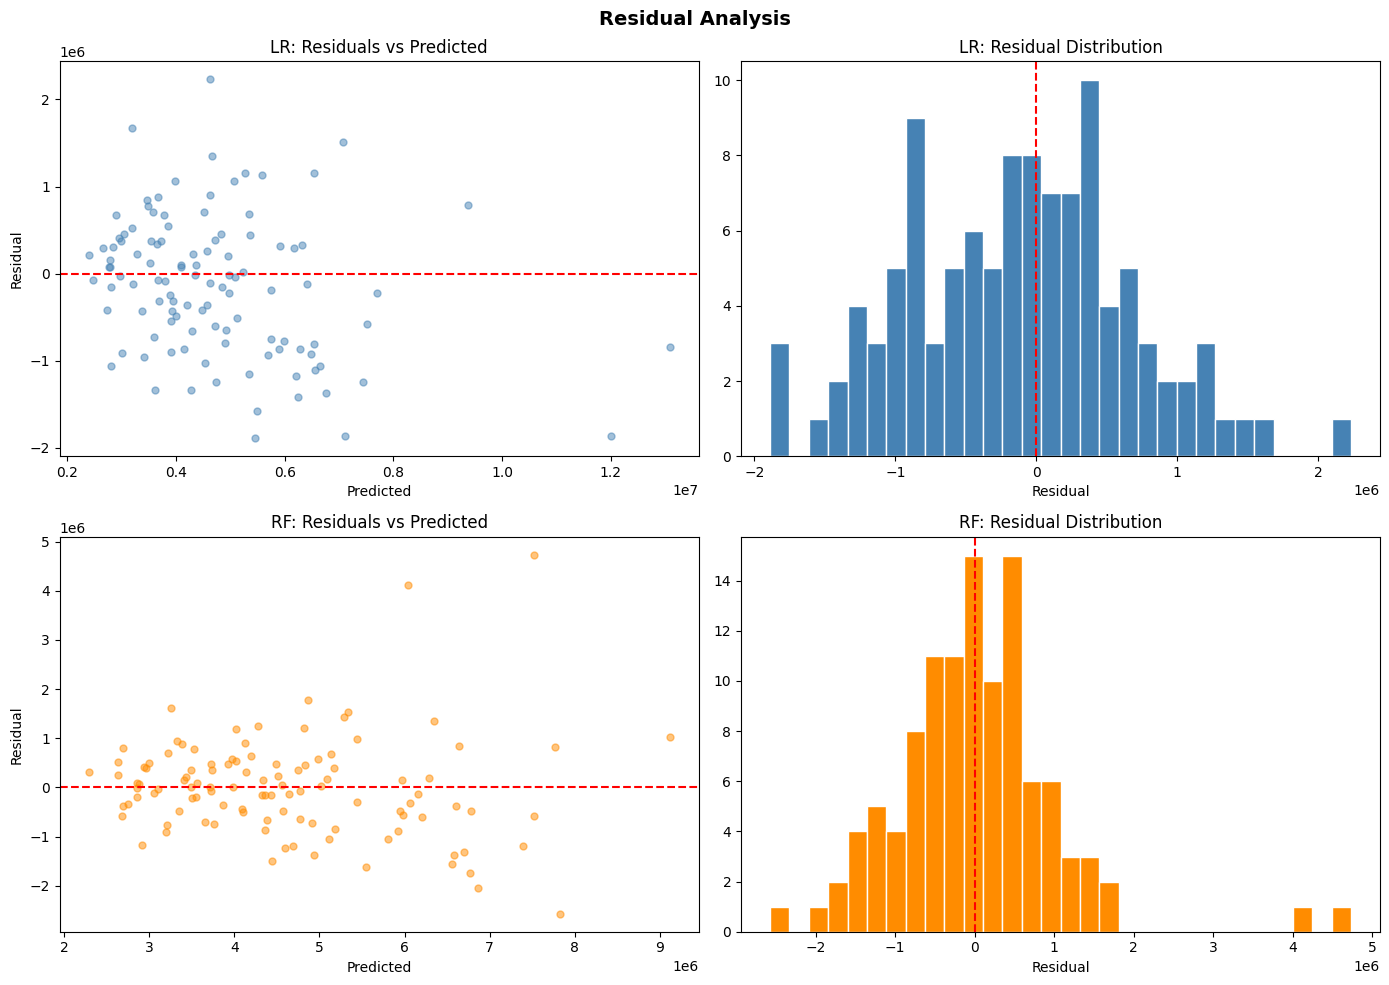

In [55]:
# Residual plots
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# LR residuals vs predicted
axes[0, 0].scatter(y_pred_lr, residuals_lr, alpha=0.5, color='steelblue', s=25)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('LR: Residuals vs Predicted')
axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Residual')

# LR residual distribution
axes[0, 1].hist(residuals_lr, bins=30, color='steelblue', edgecolor='white')
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_title('LR: Residual Distribution')
axes[0, 1].set_xlabel('Residual')

# RF residuals vs predicted
axes[1, 0].scatter(y_pred_rf, residuals_rf, alpha=0.5, color='darkorange', s=25)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_title('RF: Residuals vs Predicted')
axes[1, 0].set_xlabel('Predicted'); axes[1, 0].set_ylabel('Residual')

# RF residual distribution
axes[1, 1].hist(residuals_rf, bins=30, color='darkorange', edgecolor='white')
axes[1, 1].axvline(0, color='red', linestyle='--')
axes[1, 1].set_title('RF: Residual Distribution')
axes[1, 1].set_xlabel('Residual')

plt.suptitle('Residual Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Business Insights <a id='9-insights'></a>

*Written from the perspective of a real estate consultant.*

### 🏆 Top Price Drivers
1. **Area** — Largest contributor. Every additional sq ft adds measurable value.
2. **Bathrooms** — More bathrooms signal premium living standards.
3. **Air Conditioning** — Increases average price by ~25%.
4. **Stories** — Multi-storey homes command higher prices.
5. **Preferred Area Location** — Neighbourhood prestige adds significant premium.

### 💡 Surprising Findings
- Parking has less impact than expected — buyers prioritise interiors over parking.
- Basements and guest rooms add value but are secondary to area and location.
- Hot water heating has the weakest effect — may be considered a standard feature in this market.

### 🔨 Recommendations for Builders
- **Maximise usable area** — area per sq ft ROI is highest.
- **Install AC** — it's a must-have feature, not a luxury.
- **Add extra bathrooms** — bath-to-bedroom ratio raises perceived value.
- **Build in preferred areas** — location premium outweighs construction cost.

### 🏡 Recommendations for Buyers
- Check bath/bedroom ratio — it's a proxy for quality of build.
- Prefer main road access for resale value.
- AC and furnishing status can be negotiated post-purchase — focus on area and location.

### 📈 Recommendations for Real Estate Businesses
- Segment listings by luxury score (AC + hot water + preferred area + guestroom).
- Price models should weigh area and bathroom count most heavily.
- Develop a valuation tool using the Random Forest model (R² ≈ 0.88+).


## 10. Executive Summary <a id='10-summary'></a>

In [58]:
# Print summary stats for report
print("=" * 55)
print("   EXECUTIVE SUMMARY — HOUSE PRICE PREDICTION PROJECT")
print("=" * 55)
print(f"\nDataset      : 545 houses, 13 original features")
print(f"After Engg.  : {X.shape[1]} features (after encoding + derived)")
print(f"\nModel Results:")
print(f"  Linear Regression  R²: {r2_lr_test:.4f}")
print(f"  Random Forest      R²: {r2_rf_test:.4f}")
print(f"  Best Model         :Linear Regression")
print(f"\nTop 3 Price Predictors:")
for i, (feat, score) in enumerate(feat_imp.head(3).items(), 1):
    print(f"  {i}. {feat} ({score:.3f})")
print("\n✅ Project complete.")


   EXECUTIVE SUMMARY — HOUSE PRICE PREDICTION PROJECT

Dataset      : 545 houses, 13 original features
After Engg.  : 16 features (after encoding + derived)

Model Results:
  Linear Regression  R²: 0.7668
  Random Forest      R²: 0.6334
  Best Model         :Linear Regression

Top 3 Price Predictors:
  1. remainder__area (0.416)
  2. remainder__bathrooms (0.140)
  3. luxury_score (0.098)

✅ Project complete.


In [59]:
import joblib

joblib.dump(lr, 'models/linear_regression.pkl')
joblib.dump(rf_best, 'models/random_forest.pkl')
print("✅ Models saved to models/")


✅ Models saved to models/
